<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Sesiones/Sesion04_DiscriminativosVsGenerativos_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [ ]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pylab as plt
from datascience import *
from itertools import product
%matplotlib inline


In [ ]:
S = make_array("T", "H")
a = np.array(list(product(S, repeat=4)))
S = [ "".join(x) for x in a]
omega = make_array(S)[0]
omega

array(['TTTT', 'TTTH', 'TTHT', 'TTHH', 'THTT', 'THTH', 'THHT', 'THHH',
       'HTTT', 'HTTH', 'HTHT', 'HTHH', 'HHTT', 'HHTH', 'HHHT', 'HHHH'], dtype=object)

¿Cual es la probabilidad de obtener una cara seguida de un sello?


$A = \{HT\}$

$P_{data}(A)$

In [ ]:
Pdata = 1/16
Pdata = Table().with_columns("omega", omega, "Pdata", 1/16*np.ones(16))
Pdata
pHT = Pdata.where(omega, are.containing("HT")).column("Pdata").sum()
Pteorico=pHT
Pteorico

0.6875

In [ ]:
11/16

0.6875

Tomemos una muestra estadistica:

In [ ]:
#Observaciones
Nsample=25
Lanzamientos = Pdata.select("omega").sample(Nsample)
Lanzamientos

omega
HTHT
TTTT
TTHT
TTHH
THHH
HTTT
THTT
THTT
HHHH
TTTH


In [ ]:
# Distribucion empirica de los datos
pHTempirica = Lanzamientos.where("omega", are.containing("HT")).column("omega")
#Conteo directo
Pemp = len(pHTempirica)/Nsample
Pemp


0.72

Supongamos un modelo en el que las variables aleatorias son independientes(en el caso de la moneda coinciden) :



Estimemos los cuatro parámetros desde los datos: $\theta=(p_1,p_2,p_3,p_4)$

$P_{\theta}(A) = P(x_1)P(x_2)P(x_3)P(x_4) $



Una cara seguida de un sello  el evento es:

$A_1= \{X_1 = H,X_2=T\}$,$A_2= \{X_2 = H,X_3=T\}$,$A_3= \{X_3 = H,X_4=T\}$

Como A1 y A3 se cuentan dos veces


$p = p_1(1-p_2)+ p_2(1-p_3) + p_3(1-p_4)- p_1(1-p_2)p_3(1-p_4)$




In [ ]:
#Independendencia
#Primero intentamos aprender las probabilidades de cara en cada posición:
p1 = np.mean([x[0] == "H" for x in Lanzamientos.column("omega")])
p2 = np.mean([x[1] == "H" for x in Lanzamientos.column("omega")])
p3 = np.mean([x[2] == "H" for x in Lanzamientos.column("omega")])
p4 = np.mean([x[3] == "H" for x in Lanzamientos.column("omega")])

pcara = np.array([p1, p2, p3, p4])
psello=1-pcara
p = p1*(1-p2)+ p2*(1-p3) + p3*(1-p4) - p1*(1-p2)*p3*(1-p4)
PthetaA = p
PthetaA

0.6315904

$P_{\theta}(A)$

In [ ]:
print(Pteorico)
print(PthetaA)
print(Pemp)

0.6875
0.6965888
0.68


Como sabemos que :
p1=p2=p3=p4

La probablidad de que salga cara es 0.5 y de que salga sello es 0.5

In [ ]:
p = 0.25+0.25+0.25-0.0625
p

0.6875

In [ ]:
0.5/8

0.0625

# Problema con imágenes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

# Elegimos, por ejemplo, solamente el número 3
X = digits.images[digits.target == 3]
# Usamos pocas muestras
Nsample = 30
X = X[:Nsample]

# Binarizamos
Xbin = (X > 8).astype(int)

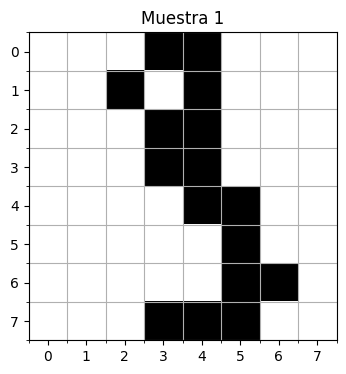

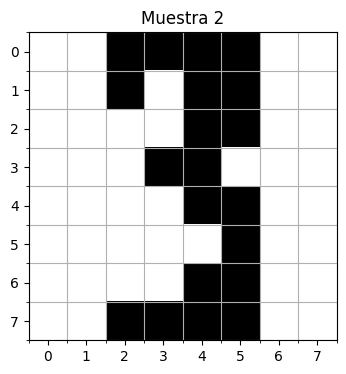

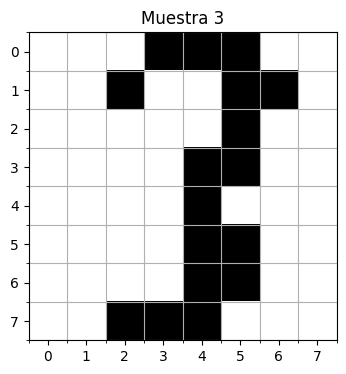

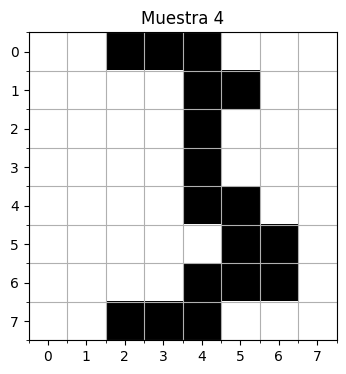

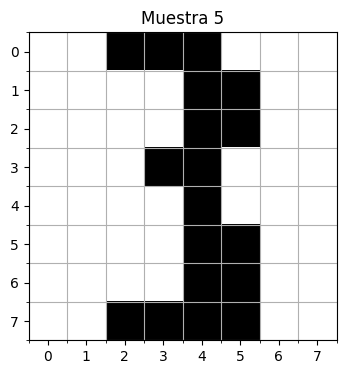

In [ ]:
for k in range(5):
    plt.figure(figsize=(4,4))
    plt.imshow(Xbin[k], cmap="gray_r", vmin=0, vmax=1)
    plt.xticks(np.arange(8))
    plt.yticks(np.arange(8))
    # Rejilla para distinguir cada píxel
    plt.xticks(np.arange(-0.5, 8, 1), minor=True)
    plt.yticks(np.arange(-0.5, 8, 1), minor=True)
    plt.grid(which="minor")
    plt.title(f"Muestra {k+1}")
    plt.show()

In [ ]:
# Probablidad de ocurrenciua de cada unos de los pixeles
p = Xbin.mean(axis=0)
p

array([[ 0.        ,  0.        ,  0.8       ,  1.        ,  0.96666667,
         0.36666667,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.66666667,  0.33333333,  0.8       ,
         0.9       ,  0.1       ,  0.        ],
       [ 0.        ,  0.        ,  0.03333333,  0.06666667,  0.83333333,
         0.76666667,  0.06666667,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.3       ,  0.96666667,
         0.4       ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.06666667,  1.        ,
         0.73333333,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.43333333,
         0.93333333,  0.13333333,  0.        ],
       [ 0.        ,  0.        ,  0.13333333,  0.33333333,  0.86666667,
         0.9       ,  0.06666667,  0.        ],
       [ 0.        ,  0.        ,  0.9       ,  1.        ,  0.8       ,
         0.3       ,  0.        ,  0.        ]])

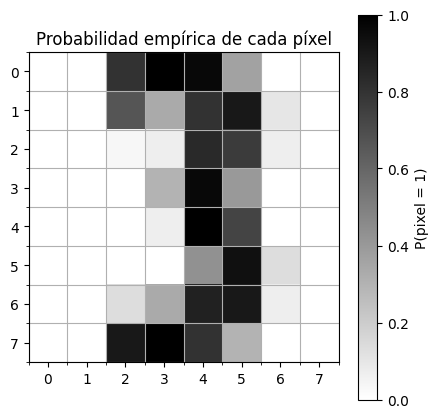

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(p, cmap="gray_r", vmin=0, vmax=1)
plt.xticks(np.arange(8))
plt.yticks(np.arange(8))
plt.xticks(np.arange(-0.5, 8, 1), minor=True)
plt.yticks(np.arange(-0.5, 8, 1), minor=True)
plt.grid(which="minor")
plt.colorbar(label="P(pixel = 1)")
plt.title("Probabilidad empírica de cada píxel")

plt.show()

# ¿Cómo generar nuevos datos?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
def aprender_modelo(digito, Nsample=100):

    X = digits.images[digits.target == digito]
    X = X[:Nsample]

    # Binarización
    Xbin = (X > 8).astype(int)

    # Probabilidad empírica de pixel = 1
    p = Xbin.mean(axis=0)

    return p

In [ ]:
p1 = aprender_modelo(1, Nsample=100)
p3 = aprender_modelo(3, Nsample=100)

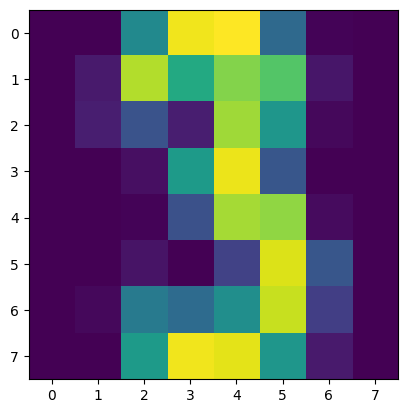

In [ ]:
plt.imshow(p3)

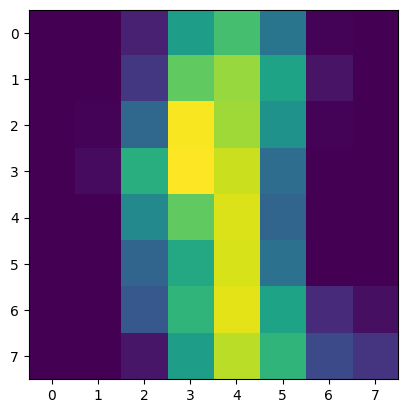

In [ ]:
plt.imshow(p1)

In [ ]:
def generar_imagen(p):
    imagen = (np.random.rand(8, 8) < p).astype(int)
    return imagen

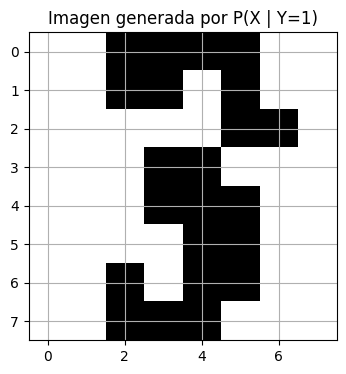

In [ ]:
x_generado_1 = generar_imagen(p3)

plt.figure(figsize=(4,4))
plt.imshow(x_generado_1, cmap="gray_r", vmin=0, vmax=1)
plt.grid()
plt.title("Imagen generada por P(X | Y=1)")
plt.show()

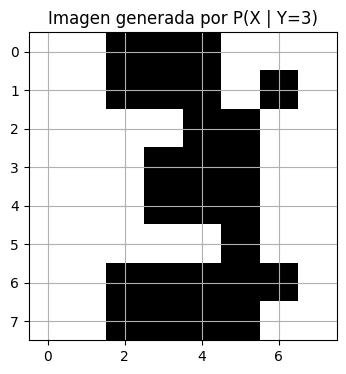

In [ ]:
x_generado_3 = generar_imagen(p3)
plt.figure(figsize=(4,4))
plt.imshow(x_generado_3, cmap="gray_r", vmin=0, vmax=1)
plt.grid()
plt.title("Imagen generada por P(X | Y=3)")
plt.show()

-----------------------------------

# Discriminativo

In [ ]:
def log_probabilidad_imagen(x, p):

    eps = 1e-6

    p = np.clip(p, eps, 1-eps)

    logP = np.sum(
        x*np.log(p)
        +
        (1-x)*np.log(1-p)
    )

    return logP

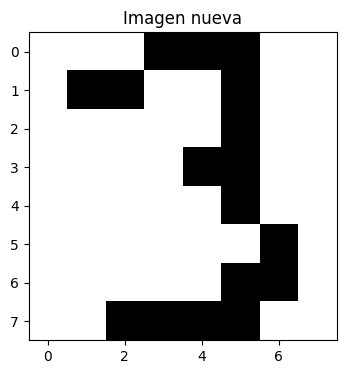

In [ ]:
X1 = digits.images[digits.target == 1]
X3 = digits.images[digits.target == 3]

# Elegimos una imagen posterior a las usadas para entrenar
x_new = (X3[120] > 8).astype(int)

plt.figure(figsize=(4,4))
plt.imshow(x_new, cmap="gray_r")
plt.title("Imagen nueva")
plt.show()

In [ ]:
logP_1 = log_probabilidad_imagen(x_new, p1)
logP_3 = log_probabilidad_imagen(x_new, p3)

print("log P(x | 1) =", logP_1)
print("log P(x | 3) =", logP_3)

log P(x | 1) = -69.0513301151
log P(x | 3) = -24.0376376265


In [ ]:
# Bayes

In [ ]:
log_score_1 = logP_1 + np.log(0.5)
log_score_3 = logP_3 + np.log(0.5)

if log_score_1 > log_score_3:
    print("Predicción: 1")
else:
    print("Predicción: 3")

Predicción: 3


In [ ]:
# funcion calsificadora
def clasificar(x, p1, p3):

    logP1 = log_probabilidad_imagen(x, p1) + np.log(0.5)
    logP3 = log_probabilidad_imagen(x, p3) + np.log(0.5)

    if logP1 > logP3:
        return 1
    else:
        return 3